<a href="https://colab.research.google.com/github/hnenda/pemrograman_HanendaNurrizqyAkbarIsnauri_mariposite_TLS26/blob/main/hanenda_hanson__pelatihan%20ganjil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hands On Pertemuan 2 - Pelatihan Data Science Ganjil 2026**

Halo Semua! Minggu lalu kita sudah kenalan sama Python, NumPy, dan Pandas. Sekarang kita masuk ke tahap yang sangat penting sebelum modeling: **Data Understanding, Exploratory Data Analysis (EDA), dan Data Preprocessing** 🐧

Kali ini kita pakai dataset **Palmer Penguins** — data pengukuran fisik penguin dari 3 spesies berbeda di Kepulauan Palmer, Antartika. Kita akan coba jawab pertanyaan: **karakteristik apa yang membedakan spesies penguin satu sama lain?**

---

**MATERIALS**

Materi yang akan kita coba praktekkan
1. Data Understanding (telusuri data pakai Pandas)
2. Tipe Data (numerik vs kategorikal)
3. EDA Univariat, Bivariat, Multivariat (+ visualisasi)
4. Data Preprocessing (missing value, duplicate, outlier)
5. Encoding (Label Encoding & One-Hot Encoding)

**ATURAN MAIN**
1. Lengkapi kode yang kosong, ditandai dengan **`___`** atau **`# TODO`**
2. Semua coba! jangan takut salah/error, kalau bingung langsung chat aja di Teams!

***


## **STEP 0: Setup**
Seperti biasa, siapkan dulu *library* yang mau kita pakai. Kali ini kita butuh lebih banyak karena mau visualisasi juga.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Sedikit pengaturan supaya visualisasi kita lebih enak dilihat (opsional, tinggal jalankan).

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

## **STEP 1: Load Data**
Dataset Palmer Penguins juga sudah disediakan oleh seaborn, jadi kita tinggal load persis seperti Titanic minggu lalu.

**Reminder:** kalau di dunia nyata biasanya kita load dari file: `df = pd.read_csv('nama_file.csv')`

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## **STEP 2: Telusuri Data Pakai Pandas**
Sebelum ngapa-ngapain, kita harus kenalan dulu sama data kita: berapa baris/kolom, seperti apa isinya secara sekilas.

### **Step 2.1: Ukuran Data**
Cek berapa jumlah baris dan kolom di dataset ini.

**Hint:** gunakan `.shape` — hasilnya `(jumlah_baris, jumlah_kolom)`

In [ ]:
print("Jumlah baris dan kolom:", penguins.shape)

Jumlah baris dan kolom: (344, 7)


### **Step 2.2: Intip Data**
Lihat beberapa baris pertama dan terakhir dari dataset.

In [ ]:
print("5 baris pertama:")
display(penguins.head())

print("\n5 baris terakhir:")
display(penguins.tail())

5 baris pertama:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



5 baris terakhir:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


### **Step 2.3: Nama Kolom & Sampel Acak**
Kadang kita juga mau lihat nama semua kolom, atau intip baris secara acak (biar tidak cuma lihat baris awal/akhir yang mungkin polanya beda).

In [ ]:
print("Nama kolom:", list(penguins.columns))

print("\n3 baris acak:")
display(penguins.sample(5))

Nama kolom: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

3 baris acak:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
267,Gentoo,Biscoe,50.5,15.9,225.0,5400.0,Male
182,Chinstrap,Dream,40.9,16.6,187.0,3200.0,Female
185,Chinstrap,Dream,51.0,18.8,203.0,4100.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
68,Adelie,Torgersen,35.9,16.6,190.0,3050.0,Female


## **STEP 3: Statistik Deskriptif & Tipe Data**
Sekarang kita masuk lebih dalam: kenali tipe data tiap kolom, dan lihat ringkasan statistiknya. Ini fondasi sebelum EDA.

### **Step 3.1: Info Umum**
`.info()` menunjukkan tipe data tiap kolom sekaligus jumlah data yang **tidak kosong** (non-null) — cara tercepat untuk mendeteksi ada tidaknya missing value.

In [ ]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


**Amati hasil di atas.** Ada berapa kolom yang punya nilai `non-null` lebih sedikit dari total baris? Itu tandanya ada **missing value** di kolom tersebut — kita akan tangani nanti di Step 5.

### **Step 3.2: Statistik Deskriptif (Kolom Numerik)**
`.describe()` memberi kita ringkasan cepat: mean, std, min, kuartil, max — untuk semua kolom numerik.

In [ ]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### **Step 3.3: Pisahkan Kolom Numerik dan Kategorikal**
Ini langkah penting: kita harus tahu mana kolom **numerik** (angka, bisa dihitung mean/std) dan mana yang **kategorikal** (label/kelompok).

**Hint:** gunakan `.select_dtypes(include=...)` — untuk numerik pakai `'number'`, untuk kategorikal pakai `'object'`

In [ ]:
kolom_numerik = penguins.select_dtypes(include='number').columns.tolist()
kolom_kategorikal = penguins.select_dtypes(include='object').columns.tolist()

print("Kolom Numerik   :", kolom_numerik)
print("Kolom Kategorikal:", kolom_kategorikal)

Kolom Numerik   : ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Kolom Kategorikal: ['species', 'island', 'sex']


### **Step 3.4: Statistik Deskriptif (Kolom Kategorikal)**
`.describe()` juga bisa dipakai untuk kolom kategorikal, tapi ringkasannya beda: jumlah unik, nilai tersering (`top`), dan berapa kali muncul (`freq`).

**Hint:** `df[kolom_kategorikal].describe()`

In [ ]:
penguins[kolom_kategorikal].describe()

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


## **STEP 4: EDA — Kolom Numerik**
Sekarang mari kita eksplorasi kolom numerik: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`. Kita akan lakukan bertahap: **univariat → bivariat → multivariat**.

### **Step 4.1 (Univariat): Distribusi `body_mass_g`**
Mari kita lihat bagaimana sebaran berat badan penguin dengan histogram.

**Hint:** `sns.histplot(data=df, x='kolom', kde=True)`

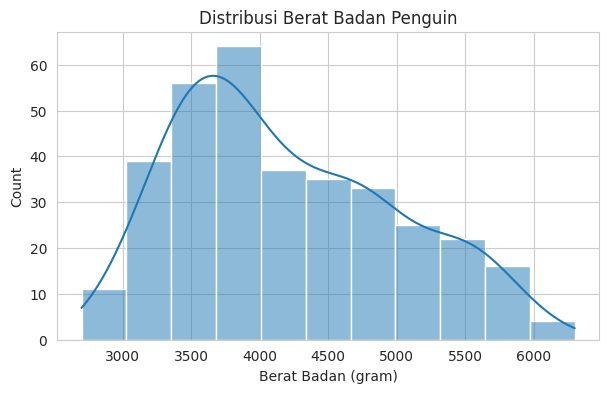

In [ ]:
sns.histplot(data=penguins, x='body_mass_g', kde=True)
plt.title("Distribusi Berat Badan Penguin")
plt.xlabel("Berat Badan (gram)")
plt.show()

> 📝 **Insight kamu:** Bagaimana bentuk distribusinya? Simetris? Skewed? Ada tanda-tanda bimodal (dua puncak)? Coba tulis observasimu di sini.
>
> *(isi jawabanmu di sini)*

### **Step 4.2 (Univariat): Boxplot Semua Kolom Numerik**
Boxplot membantu kita melihat pusat data dan mendeteksi outlier sekaligus, untuk beberapa kolom.

**Hint:** `sns.boxplot(data=df[list_kolom])`

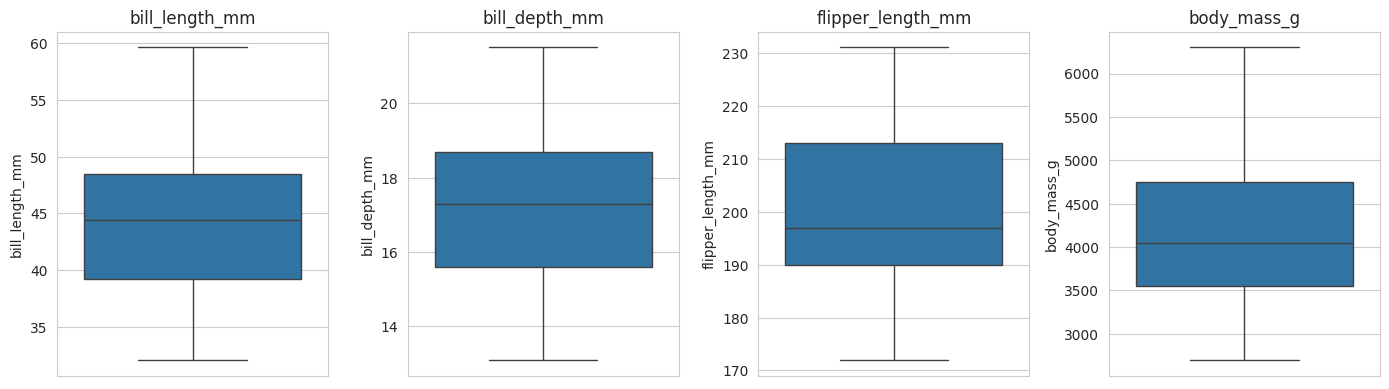

In [ ]:
fig, axes = plt.subplots(1, len(kolom_numerik), figsize=(14, 4))
for i, col in enumerate(kolom_numerik):
    sns.boxplot(data=penguins, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

> 📝 **Insight kamu:** Kolom mana yang terlihat ada outlier-nya? Atau semuanya terlihat wajar?
>
> *(isi jawabanmu di sini)*

### **Step 4.3 (Bivariat): Hubungan `bill_length_mm` vs `bill_depth_mm`**
Sekarang kita lihat hubungan antara dua variabel numerik dengan scatter plot.

**Hint:** `sns.scatterplot(data=df, x='kolom1', y='kolom2')`

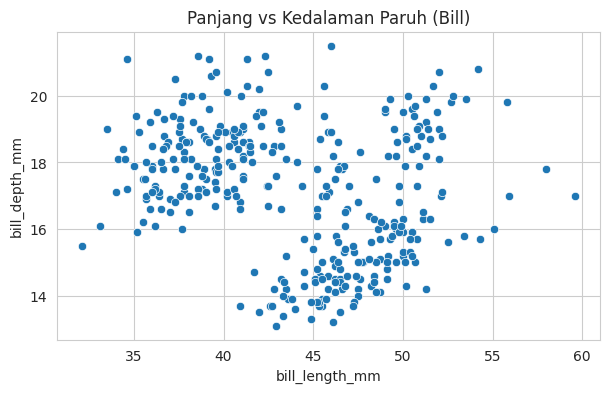

In [ ]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm')
plt.title("Panjang vs Kedalaman Paruh (Bill)")
plt.show()

Menarik, ya? Sepertinya ada pola yang agak "terpisah-pisah" alih-alih satu garis lurus. Bisa jadi ini karena ada beberapa **kelompok/kategori berbeda** yang tercampur! Kita akan buktikan nanti pas EDA kategorikal.

Sekarang mari kita hitung korelasinya secara angka.

**Hint:** `df[['kolom1','kolom2']].corr()`

In [ ]:
penguins[['bill_length_mm','bill_depth_mm']].corr()

,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.235053
bill_depth_mm,-0.235053,1.000000


> 📝 **Insight kamu:** Nilai korelasinya positif atau negatif? Apakah sesuai sama yang kamu lihat di scatter plot?
>
> *(isi jawabanmu di sini)*

### **Step 4.4 (Multivariat): Correlation Matrix & Heatmap**
Daripada cek korelasi satu-satu, mari kita lihat korelasi **semua kolom numerik sekaligus** dengan heatmap.

**Hint:** `sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap='coolwarm')`

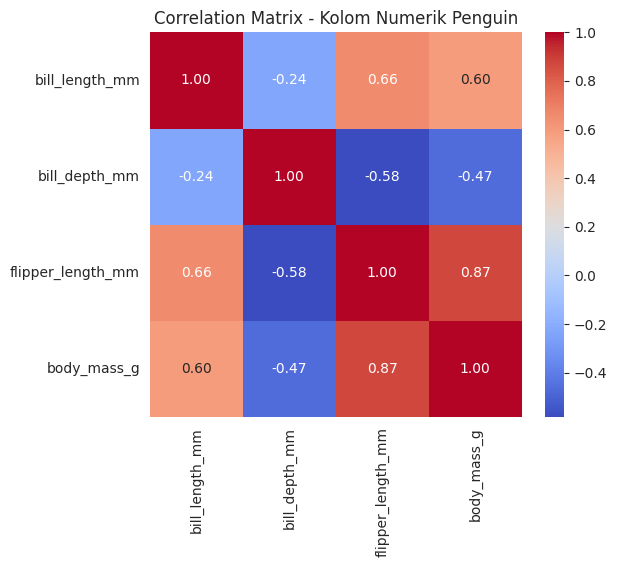

In [ ]:
plt.figure(figsize=(6, 5))
corr_matrix = penguins[kolom_numerik].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Kolom Numerik Penguin")
plt.show()

> 📝 **Insight kamu:** Pasangan kolom mana yang paling berkorelasi kuat? Masuk akal secara biologis nggak (misal, penguin yang lebih besar badannya juga lebih panjang siripnya)?
>
> *(isi jawabanmu di sini)*

## **STEP 5: EDA — Kolom Kategorikal**
Sekarang giliran kolom kategorikal: `species`, `island`, `sex`. Sama seperti sebelumnya: **univariat → bivariat → multivariat**.

### **Step 5.1 (Univariat): Distribusi Spesies**
Berapa banyak penguin dari tiap spesies?

**Hint:** `df['kolom'].value_counts()`

species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Male      22
                      Female    22
Name: count, dtype: int64


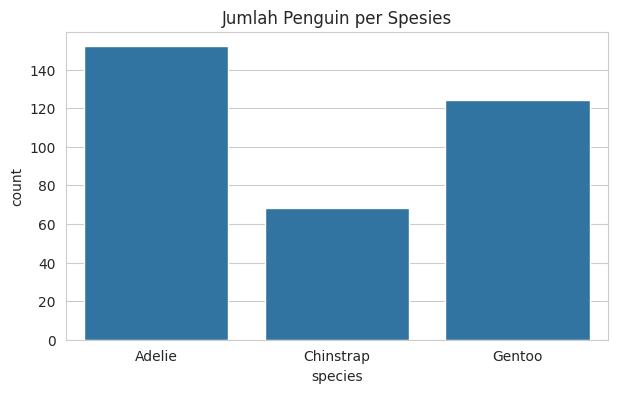

In [ ]:
print(penguins[kolom_kategorikal].value_counts())

sns.countplot(data=penguins, x='species')
plt.title("Jumlah Penguin per Spesies")
plt.show()

> 📝 **Insight kamu:** Apakah jumlah tiap spesies seimbang, atau ada yang dominan?
>
> *(isi jawabanmu di sini)*

### **Step 5.2 (Univariat): Distribusi Pulau (Pie Chart)**
Karena jumlah kategori `island` sedikit, pie chart cocok untuk melihat proporsinya.

**Hint:** `df['kolom'].value_counts().plot.pie(autopct='%1.0f%%')`

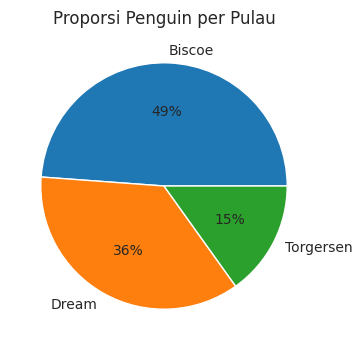

In [ ]:
penguins['island'].value_counts().plot.pie(autopct="%1.0f%%")
plt.title("Proporsi Penguin per Pulau")
plt.ylabel("")
plt.show()

### **Step 5.3 (Bivariat): Spesies vs Pulau (Kategorikal x Kategorikal)**
Sekarang mari kita lihat hubungan dua kolom kategorikal: apakah tiap spesies punya pulau favorit?

**Hint:** `pd.crosstab(df['kolom1'], df['kolom2'])`

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


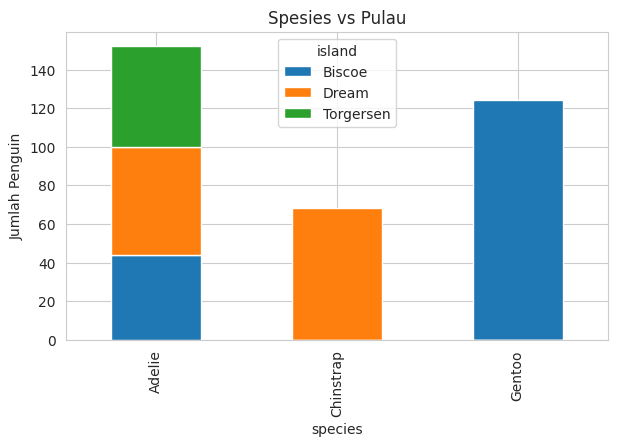

In [ ]:
tabel_silang = pd.crosstab(penguins['species'], penguins['island'])
print(tabel_silang)

tabel_silang.plot(kind="bar", stacked=True)
plt.title("Spesies vs Pulau")
plt.ylabel("Jumlah Penguin")
plt.show()

> 📝 **Insight kamu:** Apakah ada spesies yang hanya ditemukan di satu pulau tertentu? Ini bisa jadi clue penting kalau kita mau prediksi spesies nanti!
>
> *(isi jawabanmu di sini)*

### **Step 5.4 (Bivariat): Numerik x Kategorikal — Berat Badan per Spesies**
Sekarang gabungkan numerik dan kategorikal: apakah berat badan beda-beda tiap spesies?

**Hint:** `sns.boxplot(data=df, x='kolom_kategorikal', y='kolom_numerik')`

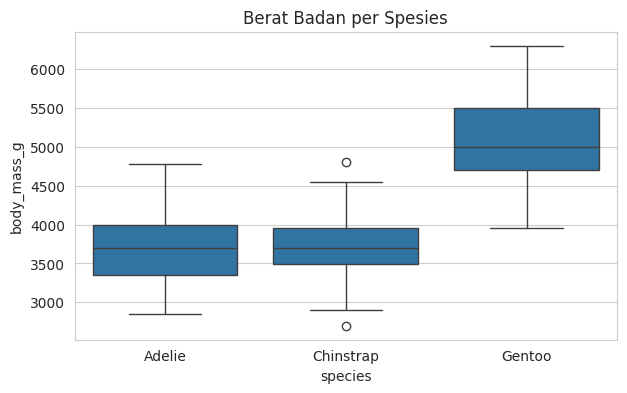

In [ ]:
sns.boxplot(data=penguins, x='species', y='body_mass_g')
plt.title("Berat Badan per Spesies")
plt.show()

> 📝 **Insight kamu:** Spesies mana yang cenderung paling berat? Apakah ini menjelaskan pola "terpisah-pisah" yang kita lihat di scatter plot Step 4.3?
>
> *(isi jawabanmu di sini)*

### **Step 5.5 (Multivariat): Pairplot dengan Warna per Spesies**
Sekarang mari kita gabungkan semuanya: lihat semua pasangan kolom numerik sekaligus, diwarnai berdasarkan spesies.

**Hint:** `sns.pairplot(df, vars=kolom_numerik, hue='kolom_kategorikal')`

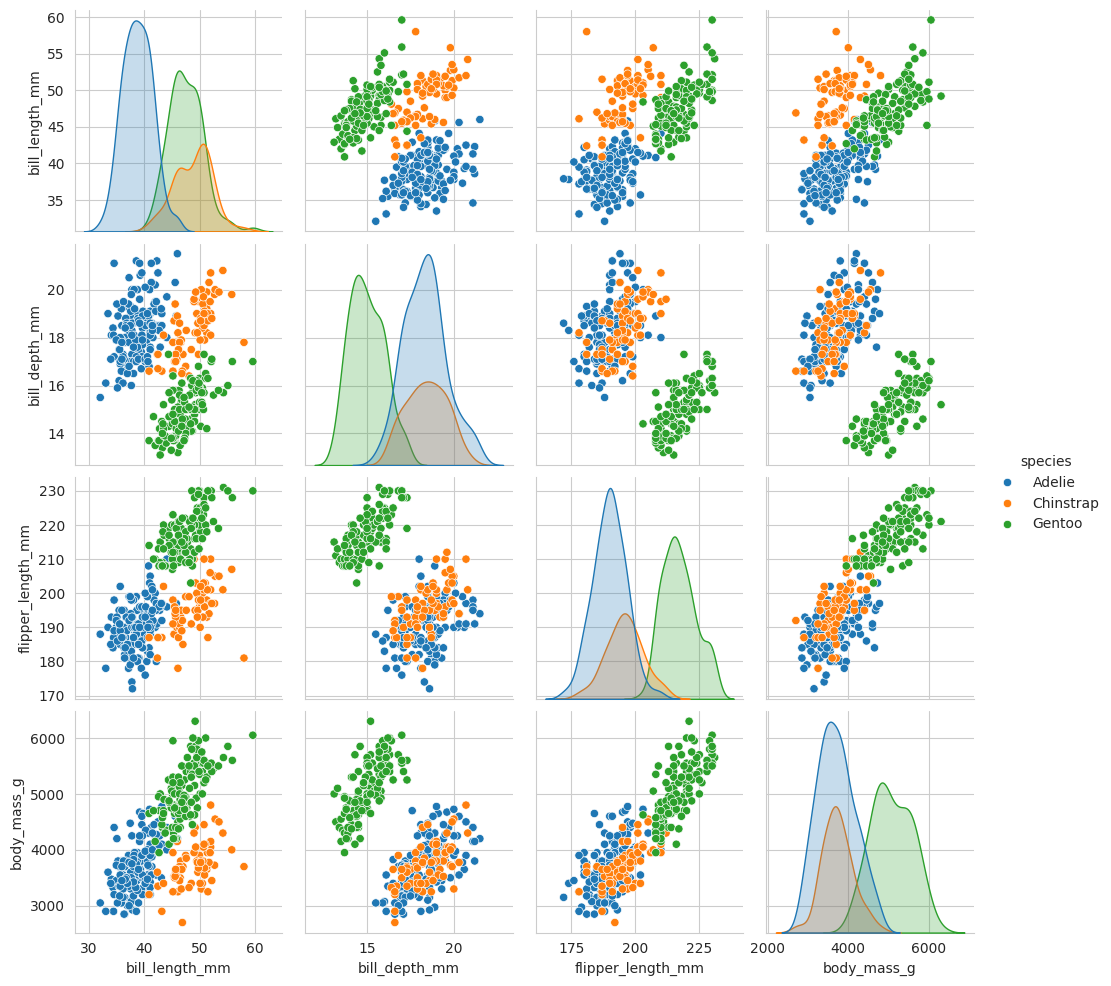

In [ ]:
sns.pairplot(penguins, vars=kolom_numerik, hue='species')
plt.show()

> 📝 **Insight kamu:** Sekarang scatter plot yang tadinya "terpisah-pisah" jadi masuk akal, kan? Variabel mana yang paling jelas memisahkan ketiga spesies?
>
> *(isi jawabanmu di sini)*

## **STEP 6: Data Preprocessing**
Berdasarkan semua yang kita temukan dari Step 2–5, sekarang saatnya membersihkan data. Kita akan tangani: **missing value**, **data duplikat**, dan **outlier**.

### **Step 6.1: Cek Missing Value**
Sudah kelihatan sekilas di `.info()` tadi, sekarang mari kita hitung persisnya per kolom.

**Hint:** `df.isnull().sum()`

In [ ]:
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**Amati:** kolom mana saja yang punya missing value, dan berapa persen dari total data?

**Hint:** kalikan hasil di atas dengan `100 / len(df)` untuk dapat persentase.

In [ ]:
(penguins.isnull().sum() / len(penguins) * 100).round(2)

,0
species,0.00
island,0.00
bill_length_mm,0.58
bill_depth_mm,0.58
flipper_length_mm,0.58
body_mass_g,0.58
sex,3.20


### **Step 6.2: Tangani Missing Value — Kolom Numerik**
Untuk kolom numerik (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), missing valuenya sedikit sekali (cuma 2 baris). Kita akan **imputasi** dengan **median** (lebih tahan terhadap outlier dibanding mean).

**Hint:** `df['kolom'].fillna(df['kolom'].median())`

In [ ]:
penguins_bersih = penguins.copy()

for col in ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]:
    median_value = penguins_bersih[col].median()
    penguins_bersih[col] = penguins_bersih[col].fillna(median_value)

print("Missing value kolom numerik setelah imputasi:")
print(penguins_bersih[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].isnull().sum())

Missing value kolom numerik setelah imputasi:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


### **Step 6.3: Tangani Missing Value — Kolom Kategorikal**
Untuk kolom kategorikal `sex`, missing value-nya agak lebih banyak (11 baris). Untuk kategorikal, kita imputasi dengan **modus** (nilai yang paling sering muncul), bukan mean/median.

**Hint:** `df['kolom'].mode()[0]` untuk mendapat nilai modus.

In [ ]:
modus_sex = penguins_bersih["sex"].mode()[0]
print("Modus kolom 'sex':", modus_sex)

penguins_bersih["sex"] = penguins_bersih["sex"].fillna(modus_sex)

print("\nTotal missing value setelah semua imputasi:")
print(penguins_bersih.isnull().sum())

Modus kolom 'sex': Male

Total missing value setelah semua imputasi:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### **Step 6.4: Cek Data Duplikat**
Selain missing value, kita juga perlu cek apakah ada baris yang persis sama (duplikat) di dataset.

**Hint:** `df.duplicated().sum()` menghitung jumlah baris duplikat.

In [ ]:
jumlah_duplikat = penguins_bersih.duplicated().sum()
print("Jumlah baris duplikat:", jumlah_duplikat)

Jumlah baris duplikat: 0


> 📝 **Insight kamu:** Kalau ada duplikat, sebaiknya di-drop pakai `df.drop_duplicates()`. Kalau tidak ada (seperti kemungkinan besar di dataset ini), tidak perlu tindakan apa-apa.

### **Step 6.5: Cek Ulang Outlier dengan IQR**
Balik lagi ke boxplot Step 4.2 — sekarang mari kita hitung batas outlier secara matematis pakai metode **IQR (Interquartile Range)**.

Rumusnya:
- `IQR = Q3 - Q1`
- Batas bawah = `Q1 - 1.5 * IQR`
- Batas atas = `Q3 + 1.5 * IQR`
- Nilai di luar batas ini dianggap outlier

**Hint:** gunakan `.quantile(0.25)` dan `.quantile(0.75)`

In [ ]:
for col in kolom_numerik:
    Q1 = penguins_bersih[col].quantile(0.25)
    Q3 = penguins_bersih[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outliers = penguins_bersih[(penguins_bersih[col] < batas_bawah) | (penguins_bersih[col] > batas_atas)]
    print(f"{col}: {len(outliers)} outlier terdeteksi")

bill_length_mm: 0 outlier terdeteksi
bill_depth_mm: 0 outlier terdeteksi
flipper_length_mm: 0 outlier terdeteksi
body_mass_g: 0 outlier terdeteksi


> 📝 **Insight kamu:** Ada kolom yang punya outlier signifikan? Kalau ada, apakah itu kesalahan input atau memang variasi alami penguin (misal penguin yang memang jauh lebih besar/kecil dari biasanya)? Ingat, tidak semua outlier harus dibuang!

## **STEP 7: Encoding**
Model Machine Learning hanya bisa membaca angka, bukan teks. Karena itu, kolom kategorikal (`species`, `island`, `sex`) perlu diubah jadi angka lewat proses **encoding**. Ada dua teknik populer yang akan kita coba: **Label Encoding** dan **One-Hot Encoding**.

### **Step 7.1: Label Encoding**
Label Encoding mengubah tiap kategori menjadi angka urut (0, 1, 2, ...). Cocok untuk data **ordinal** (ada urutan) — tapi hati-hati kalau dipakai untuk data **nominal** (tanpa urutan), karena model bisa salah paham seolah-olah "2 lebih besar dari 0".

**Hint:** `from sklearn.preprocessing import LabelEncoder`, lalu `le.fit_transform(df['kolom'])`

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
penguins_bersih["sex_encoded"] = le.fit_transform(penguins_bersih["sex"])

print(penguins_bersih[["sex", "sex_encoded"]].drop_duplicates())

      sex  sex_encoded
0    Male            1
1  Female            0


> 📝 **Insight kamu:** Kolom `sex` cuma punya 2 kategori (Male/Female) — untuk kasus biner seperti ini, Label Encoding sebenarnya cukup aman dipakai. Coba tebak, kenapa?

### **Step 7.2: One-Hot Encoding**
Untuk kolom dengan lebih dari 2 kategori dan **tidak ada urutan** (nominal) seperti `species` dan `island`, lebih aman pakai **One-Hot Encoding** — tiap kategori jadi kolom baru berisi 0/1.

**Hint:** `pd.get_dummies(df, columns=['kolom1', 'kolom2'])`

In [ ]:
penguins_encoded = pd.get_dummies(penguins_bersih, columns=['species', 'island'])

print("Kolom sebelum One-Hot Encoding:", penguins_bersih.shape[1])
print("Kolom setelah One-Hot Encoding:", penguins_encoded.shape[1])
penguins_encoded.head()

Kolom sebelum One-Hot Encoding: 8
Kolom setelah One-Hot Encoding: 12


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,sex_encoded,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
0,39.10,18.7,181.0,3750.0,Male,1,True,False,False,False,False,True
1,39.50,17.4,186.0,3800.0,Female,0,True,False,False,False,False,True
2,40.30,18.0,195.0,3250.0,Female,0,True,False,False,False,False,True
3,44.45,17.3,197.0,4050.0,Male,1,True,False,False,False,False,True
4,36.70,19.3,193.0,3450.0,Female,0,True,False,False,False,False,True


> 📝 **Insight kamu:** Kenapa jumlah kolom bertambah? Coba lihat nama-nama kolom barunya — polanya seperti apa?

In [ ]:
print(list(penguins_encoded.columns))

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'sex_encoded', 'species_Adelie', 'species_Chinstrap', 'species_Gentoo', 'island_Biscoe', 'island_Dream', 'island_Torgersen']


## **SELESAIII**

Selamat! Kamu baru saja menyelesaikan siklus lengkap **Data Understanding → EDA → Preprocessing → Encoding** — persis alur yang akan kamu pakai berulang kali sepanjang perjalanan Data Science kamu 🐧

**Ringkasan yang sudah kita lakukan:**
1. Load data dan telusuri strukturnya dengan Pandas
2. Cek statistik deskriptif & pisahkan kolom numerik vs kategorikal
3. EDA numerik (univariat → bivariat → multivariat) dan temukan insight
4. EDA kategorikal (univariat → bivariat → multivariat) dan temukan insight
5. Bersihkan missing value, cek duplikat, dan cek outlier
6. Encoding kolom kategorikal jadi angka (Label Encoding & One-Hot Encoding)

**Next Step:** Modul Machine Learning — sekarang datanya sudah bersih dan siap masuk ke model! 🚀
